In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from tqdm import tqdm
import re
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

from warnings import filterwarnings
filterwarnings('ignore')

sns.set_style('darkgrid')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загрузка датасета

- Algo - 0
- Analysis - 1
- NN - 2
- Optim - 3
- SQL - 4

In [8]:
import h5py

In [3]:
with h5py.File('/kaggle/input/5-classes-clean/embeddings_dataset.h5', 'r') as f:
    embeddings = np.squeeze(f['embeddings'][:])
    labels = f['labels'][:]

In [4]:
embeddings.shape

(21254, 768)

In [6]:
labels.shape

(21254,)

In [5]:
pd.value_counts(labels)

4    7350
1    4562
2    3960
0    3739
3    1643
Name: count, dtype: int64

# Классический МЛ

In [11]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, PrecisionRecallDisplay, RocCurveDisplay

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, 
    test_size=0.15, 
    stratify=labels, 
    random_state=42,
    shuffle=True
)

In [27]:
pd.Series(y_train).value_counts()

4    6247
1    3878
2    3366
0    3178
3    1396
Name: count, dtype: int64

In [28]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [29]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Полученное accuracy: {accuracy:.4f}")

Полученное accuracy: 0.7962


## lgbm

In [10]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import time


def tune_lightgbm(X, y, n_iter=50, cv_folds=5):
    model = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=5,
        random_state=42,
        n_jobs=1,
        verbose=-1,
        device='gpu',  
        gpu_platform_id=0,  
        gpu_device_id=0, 
        gpu_use_dp=True,  
        max_bin=63
    )
    
    param_dist = {
        'n_estimators': [300, 400, 500],
        'num_leaves': [31, 63],
        'max_depth': [5, 6, 7]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=20,
        cv=cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=1,
        verbose=1
    )

    X_float32 = X.astype(np.float32)

    start = time.time()
    random_search.fit(X_float32, y)
    end = time.time()
    
    print(f"Время выполнения в минутах: {(end-start)/60:.2f}")
    print(f"Лучшие параметры: {random_search.best_params_}")
    print(f"Лучшая точность: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_, random_search.best_params_

### С одним гиперпараметром

In [29]:
from warnings import filterwarnings
filterwarnings('ignore')


best_lgbm, best_lgbm_params = tune_lightgbm(X_train, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Время выполнения в минутах: 4.21
Лучшие параметры: {'n_estimators': 300}
Лучшая точность: 0.8898


## xgboost

In [17]:
import xgboost as xgb

def tune_xgboost_gpu(X, y, n_iter=50, cv_folds=3):
    model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=5,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        tree_method='gpu_hist',  
        predictor='gpu_predictor',  
        gpu_id=0, 
        sampling_method='gradient_based',
        verbosity=0
    )
    
    param_dist = {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [3, 4, 5, 6, 7, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
        'min_child_weight': [1, 3, 5, 7],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2, 0.3],
        'reg_alpha': [0, 0.01, 0.1, 1.0],
        'reg_lambda': [0, 0.01, 0.1, 1.0],
        'max_bin': [256, 512]
    }
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    X_float32 = X.astype(np.float32)
    
    start = time.time()
    random_search.fit(X_float32, y)
    end = time.time()
    
    print(f"Время выполнения в минутах: {(end-start)/60:.2f}")
    print(f"Лучшие параметры: {random_search.best_params_}")
    print(f"Лучшая точность: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_, random_search.best_params_

### С одним гиперпараметром

In [53]:
best_xgb, best_xgb_params = tune_xgboost_gpu(X_train, y_train, n_iter=20)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Время выполнения в минутах: 0.33
Лучшие параметры: {'n_estimators': 100}
Лучшая точность: 0.8726


### Несколько

In [18]:
best_xgb, best_xgb_params = tune_xgboost_gpu(X_train, y_train, n_iter=20)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Время выполнения в минутах: 13.34
Лучшие параметры: {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 4, 'max_bin': 256, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
Лучшая точность: 0.8865


## catboost

In [21]:
from catboost import CatBoostClassifier

def tune_catboost_gpu(X, y, n_iter=30, cv_folds=5):
    model = CatBoostClassifier(
        loss_function='MultiClass',
        random_seed=42,
        verbose=False,
        task_type='GPU', 
        devices='0', 
        early_stopping_rounds=50,
        eval_metric='Accuracy'
    )
    
    param_dist = {
        'iterations': [200, 300, 400, 500],
        'depth': [3, 4, 5, 6, 7, 8, 9, 10],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'border_count': [32, 64, 128, 254], 
        'bagging_temperature': [0, 1, 2, 5],
        'random_strength': [0, 1, 2, 5],
    }
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=1,
        verbose=1
    )
    
    start = time.time()
    random_search.fit(X, y)
    end = time.time()
    
    print(f"Время выполнения в минутах: {(end-start)/60:.2f}")
    print(f"Лучшие параметры: {random_search.best_params_}")
    print(f"Лучшая точность: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_, random_search.best_params_

### С одним гиперпараметром

In [16]:
best_cat, best_cat_params = tune_catboost_gpu(X_train, y_train, n_iter=20)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Время выполнения в минутах: 0.81
Лучшие параметры: {'iterations': 200}
Лучшая точность: 0.8562


### Несколько

In [22]:
best_cat, best_cat_params = tune_catboost_gpu(X_train, y_train, n_iter=20)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Время выполнения в минутах: 31.19
Лучшие параметры: {'random_strength': 5, 'learning_rate': 0.15, 'l2_leaf_reg': 1, 'iterations': 400, 'depth': 9, 'border_count': 254, 'bagging_temperature': 2}
Лучшая точность: 0.8654


# DL

In [5]:
class SimpleNet(nn.Module):
    def __init__(self, input_size=768, num_classes=5):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.layer4 = nn.Linear(128, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.layer3(x)))
        x = self.dropout(x)
        x = self.layer4(x)
        return x

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim


def train_simple_model(X_train, y_train, X_test=None, y_test=None, epochs=50, batch_size=64):
    class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train), 
    y=y_train
    )
    class_weights = torch.FloatTensor(class_weights).to(device)
    X_train = torch.FloatTensor(X_train)
    y_train = torch.LongTensor(y_train)
    if X_test is not None:
        X_test = torch.FloatTensor(X_test)
    if y_test is not None:
        y_test = torch.LongTensor(y_test)
    
    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    
    
    model = SimpleNet().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

        if X_test is not None and y_test is not None:
            if (epoch + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    test_outputs = model(X_test.to(device))
                    _, predicted = torch.max(test_outputs, 1)
                    acc = accuracy_score(y_test, predicted.cpu())
                    print(f"Эпоха {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")
    
    return model

In [126]:
X_train_neural, X_val_neural, y_train_neural, y_val_neural = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

In [123]:
model = train_simple_model(X_train_neural, y_train_neural, X_val_neural, y_val_neural, epochs=50)

model.eval()
with torch.no_grad():
    X_val_tensor = torch.FloatTensor(X_val_neural).to('cuda' if torch.cuda.is_available() else 'cpu')
    outputs = model(X_val_tensor)
    _, predictions = torch.max(outputs, 1)
    final_acc = accuracy_score(y_val_neural, predictions.cpu())
    print(f"\nФинальная точность на тесте: {final_acc:.4f}")

Эпоха 10/100, Loss: 0.1412, Test Acc: 0.9292
Эпоха 20/100, Loss: 0.0688, Test Acc: 0.9330
Эпоха 30/100, Loss: 0.0541, Test Acc: 0.9419
Эпоха 40/100, Loss: 0.0383, Test Acc: 0.9369
Эпоха 50/100, Loss: 0.0396, Test Acc: 0.9458
Эпоха 60/100, Loss: 0.0269, Test Acc: 0.9413
Эпоха 70/100, Loss: 0.0215, Test Acc: 0.9419
Эпоха 80/100, Loss: 0.0342, Test Acc: 0.9419
Эпоха 90/100, Loss: 0.0373, Test Acc: 0.9447
Эпоха 100/100, Loss: 0.0219, Test Acc: 0.9430

Финальная точность на тесте: 0.9430


## Смотрим среднее

In [11]:
def train_multiple_times(X_train, y_train, X_val, y_val, n_runs, epochs=50):
    accuracies = []
    
    for run in range(n_runs):
        print(f"\n=== Запуск {run+1}/{n_runs} ===")
        model = train_simple_model(X_train, y_train, X_val, y_val, epochs=epochs)
        
        model.eval()
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_val).to(device)
            outputs = model(X_val_tensor)
            _, preds = torch.max(outputs, 1)
            acc = accuracy_score(y_val, preds.cpu())
            accuracies.append(acc)
        
        print(f"Точность: {acc:.4f}")
    
    accuracies = np.array(accuracies)
    print(f"\n{'='*40}")
    print(f"Средняя точность: {accuracies.mean():.4f}")
    print(f"Стандартное отклонение: {accuracies.std():.4f}")
    print(f"Мин/Макс: {accuracies.min():.4f}/{accuracies.max():.4f}")
    
    return accuracies

#accuracies = train_multiple_times(X_train_neural, y_train_neural, X_val_neural, y_val_neural, n_runs=30)

# Сохранение нейронки

In [10]:
model = train_simple_model(embeddings, labels, epochs=50)

In [12]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': 768,
    'num_classes': 5,
    'architecture': 'SimpleNet'
}, 'article_classifier.pth')

# Итоговая модель

In [6]:
class SimpleNet(nn.Module):
    def __init__(self, input_size=768, num_classes=11):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.layer4 = nn.Linear(128, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.layer3(x)))
        x = self.dropout(x)
        x = self.layer4(x)
        return x

In [9]:
with h5py.File('/kaggle/input/datasets/arturosaf8/final-embeddings/full_embeddings_dataset.h5', 'r') as f:
    embeddings = np.squeeze(f['embeddings'][:])
    labels = f['labels'][:]

- Algo - 0
- Analysis - 1
- NN - 2
- Optim - 3
- SQL - 4
- Software_engineering - 5
- CIS_design - 6
- Software_testing - 7
- Project_management - 8
- Philosophy - 9
- Python - 10

In [13]:
for i in pd.value_counts(labels).sort_index():
    print(i / 52986 * 100)

7.056580983656061
8.607934171290529
7.473672290793795
3.100819084286415
13.871588721549088
10.234778998225947
4.316234477031669
8.728720794172046
11.146340542784888
17.062997772996642
8.400332163212925


In [8]:
labels.shape

(52986,)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    embeddings, labels, 
    test_size=0.15, 
    stratify=labels, 
    random_state=42,
    shuffle=True
)

In [21]:
train_multiple_times(X_train, y_train, X_val, y_val, n_runs=30)


=== Запуск 1/30 ===
Эпоха 10/50, Loss: 0.2205, Test Acc: 0.9177
Эпоха 20/50, Loss: 0.1262, Test Acc: 0.9268
Эпоха 30/50, Loss: 0.0929, Test Acc: 0.9298
Эпоха 40/50, Loss: 0.0732, Test Acc: 0.9292
Эпоха 50/50, Loss: 0.0633, Test Acc: 0.9312
Точность: 0.9312

=== Запуск 2/30 ===
Эпоха 10/50, Loss: 0.2249, Test Acc: 0.9176
Эпоха 20/50, Loss: 0.1263, Test Acc: 0.9288
Эпоха 30/50, Loss: 0.0933, Test Acc: 0.9314
Эпоха 40/50, Loss: 0.0740, Test Acc: 0.9353
Эпоха 50/50, Loss: 0.0662, Test Acc: 0.9362
Точность: 0.9362

=== Запуск 3/30 ===
Эпоха 10/50, Loss: 0.2266, Test Acc: 0.9199
Эпоха 20/50, Loss: 0.1268, Test Acc: 0.9253
Эпоха 30/50, Loss: 0.0943, Test Acc: 0.9266
Эпоха 40/50, Loss: 0.0742, Test Acc: 0.9323
Эпоха 50/50, Loss: 0.0686, Test Acc: 0.9353
Точность: 0.9353

=== Запуск 4/30 ===
Эпоха 10/50, Loss: 0.2216, Test Acc: 0.9176
Эпоха 20/50, Loss: 0.1312, Test Acc: 0.9299
Эпоха 30/50, Loss: 0.0946, Test Acc: 0.9311
Эпоха 40/50, Loss: 0.0739, Test Acc: 0.9312
Эпоха 50/50, Loss: 0.0671, Te

array([0.93117765, 0.93621037, 0.93532964, 0.9329391 , 0.93180674,
       0.9357071 , 0.93407146, 0.93444892, 0.93507801, 0.93344238,
       0.93142929, 0.93507801, 0.93444892, 0.9357071 , 0.93205838,
       0.93067438, 0.93482637, 0.93444892, 0.93319074, 0.93319074,
       0.93444892, 0.93067438, 0.93193256, 0.93444892, 0.93319074,
       0.93532964, 0.9321842 , 0.93054857, 0.93256165, 0.9321842 ])

In [2]:
indices = np.random.permutation(len(embeddings))
embeddings_shuffled = embeddings[indices]
labels_shuffled = labels[indices]

NameError: name 'embeddings' is not defined

In [43]:
model = train_simple_model(embeddings_shuffled, labels_shuffled, epochs=50)

In [44]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': 768,
    'num_classes': 11,
    'architecture': 'SimpleNet'
}, 'final_article_classifier.pth')

In [45]:
checkpoint = torch.load('final_article_classifier.pth', map_location=device)

In [46]:
checkpoint['num_classes']

11

# Смотрим матрицу ошибок

In [1]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def train_simple_model(X_train, y_train, X_test=None, y_test=None, epochs=50, batch_size=64, class_names=None):
    class_weights = compute_class_weight(
        'balanced', 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weights = torch.FloatTensor(class_weights).to(device)
    X_train = torch.FloatTensor(X_train)
    y_train = torch.LongTensor(y_train)
    if X_test is not None:
        X_test = torch.FloatTensor(X_test)
    if y_test is not None:
        y_test = torch.LongTensor(y_test)
    
    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    
    model = SimpleNet().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

        if X_test is not None and y_test is not None:
            if (epoch + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    test_outputs = model(X_test.to(device))
                    _, predicted = torch.max(test_outputs, 1)
                    acc = accuracy_score(y_test.cpu(), predicted.cpu())
                    print(f"Эпоха {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")
    
    if X_test is not None and y_test is not None:
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            _, predicted = torch.max(test_outputs, 1)
            y_true_np = y_test.cpu().numpy()
            y_pred_np = predicted.cpu().numpy()
            
            acc = accuracy_score(y_true_np, y_pred_np)
            print(f"\n=== Финальная точность: {acc:.4f} ===")
            print("\nОтчёт по классам:")
            print(classification_report(y_true_np, y_pred_np, zero_division=0))
            
            cm = confusion_matrix(y_true_np, y_pred_np)
            
            plt.figure(figsize=(8, 6))
            
            if class_names is None:
                class_names = [str(i) for i in range(len(np.unique(y_train)))]
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=class_names, yticklabels=class_names)
            plt.xlabel('Предсказанный класс')
            plt.ylabel('Истинный класс')
            plt.title('Матрица ошибок')
            plt.tight_layout()
            plt.show()
    
    return model

Эпоха 10/50, Loss: 0.2219, Test Acc: 0.9243
Эпоха 20/50, Loss: 0.1326, Test Acc: 0.9269
Эпоха 30/50, Loss: 0.0918, Test Acc: 0.9336
Эпоха 40/50, Loss: 0.0799, Test Acc: 0.9303
Эпоха 50/50, Loss: 0.0713, Test Acc: 0.9356

=== Финальная точность: 0.9356 ===

Отчёт по классам:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       561
           1       0.90      0.92      0.91       684
           2       0.93      0.88      0.90       594
           3       0.94      0.95      0.95       246
           4       0.98      0.92      0.95      1103
           5       0.93      0.93      0.93       813
           6       0.85      0.83      0.84       343
           7       0.93      0.95      0.94       694
           8       0.95      0.95      0.95       886
           9       0.98      0.99      0.99      1356
          10       0.91      0.94      0.92       668

    accuracy                           0.94      7948
   macro avg       0.

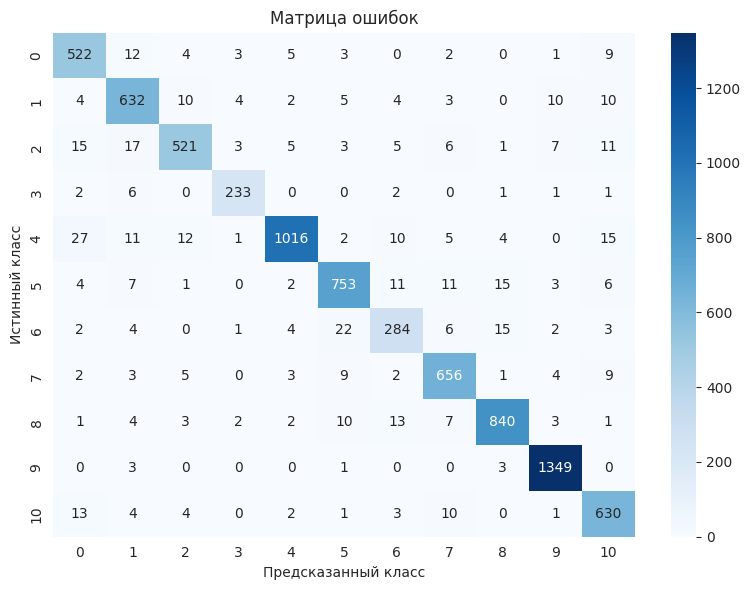

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    embeddings, labels, 
    test_size=0.15, 
    stratify=labels, 
    random_state=42,
    shuffle=True
)

model = train_simple_model(X_train, y_train, X_val, y_val, epochs=50)

- Algo - 0
- Analysis - 1
- NN - 2
- Optim - 3
- SQL - 4
- Software_engineering - 5
- CIS_design - 6
- Software_testing - 7
- Project_management - 8
- Philosophy - 9
- Python - 10